# Healthcare Multivariate Analysis, PCA, and Baseline Regression

**Author:** Sung Song  
**Project type:** Multivariate exploratory data analysis, PCA, and baseline regression  
**Datasets:** Diabetes Health Indicators, Life Expectancy, and SUPPORT2

## Project overview

This notebook applies multivariate exploratory analysis to three healthcare-related datasets. The workflow uses correlation heatmaps, bubble plots, principal component analysis, and baseline linear regression to evaluate feature relationships, dimensionality reduction potential, and predictive usefulness.

**Note:** This version intentionally keeps the saved printouts, tables, and plots from the original run so the notebook can be reviewed on GitHub without rerunning the data files.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## Analysis plan

For each dataset, this notebook reviews:

- Multivariate correlation structure using heatmaps
- Bubble plots to examine three or more variables at once
- PCA directions, PC1 projections, and explained variance
- Linear regression using different feature sets
- Brief conclusions about outliers, dimensionality reduction, and modeling usefulness


# 1. Diabetes Health Indicators

The Diabetes Health Indicators dataset contains survey-based diabetes status and related clinical, lifestyle, and demographic variables. This section examines how diabetes status relates to blood pressure, cholesterol, BMI, age, general health, physical activity, and other risk indicators.


## Diabetes: Heatmaps

The heatmaps summarize the numeric correlation structure and show diabetes prevalence across selected ordinal or binary health indicators.


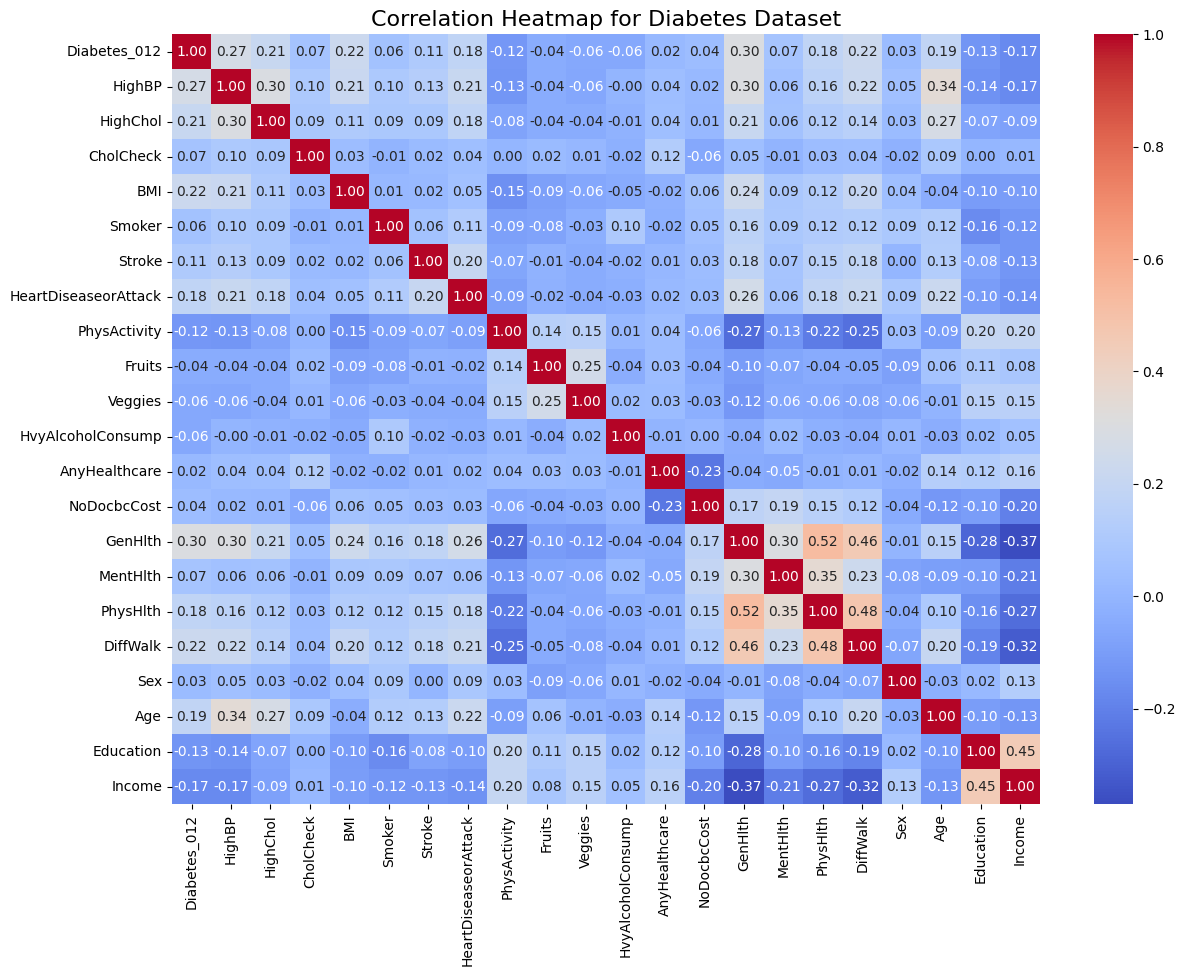

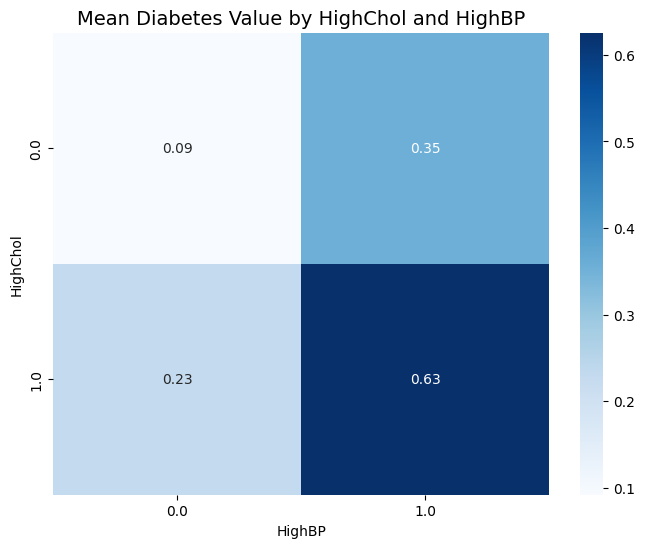

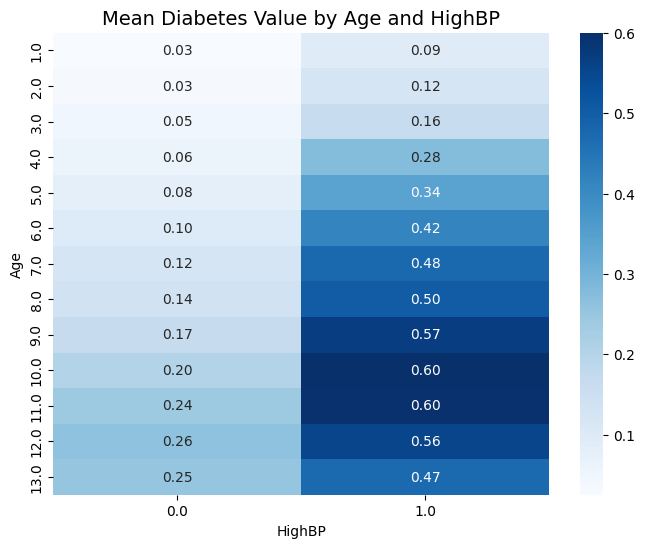

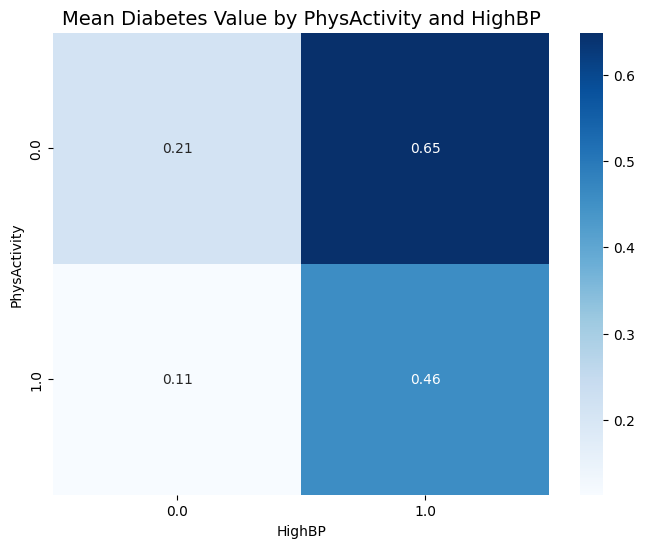

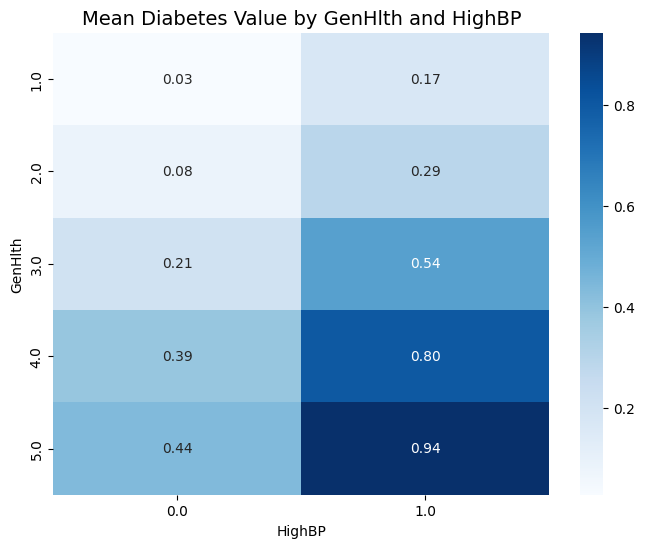

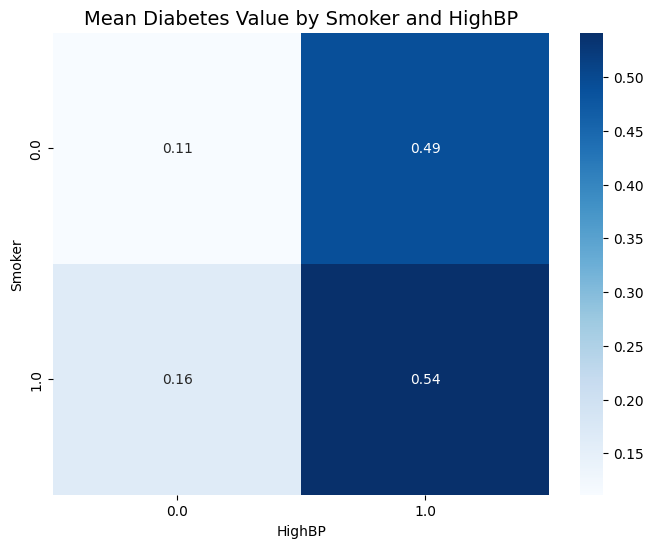

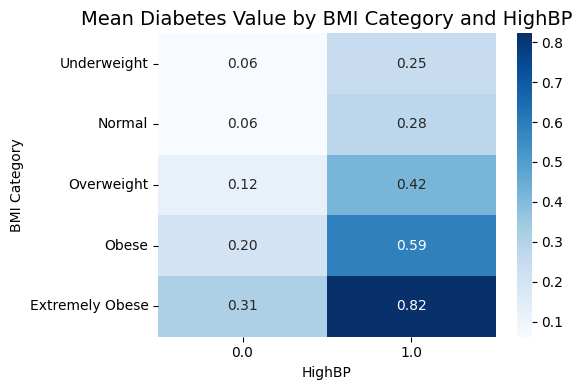

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(DATA_DIR / 'diabetes_012_health_indicators_BRFSS2015.csv')

# Correlation matrix for numeric variables
corr = df.corr(numeric_only=True)

# Regular Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
#sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap for Diabetes Dataset", fontsize=16)
plt.show()

#Pivot Table Heatmaps (Target = Diabetes_012)

# most relevant categorical or ordinal features for pivoting
features = ['HighBP', 'HighChol', 'Age', 'PhysActivity', 'GenHlth', 'Smoker']

# pivot heatmaps comparing each feature vs Diabetes prevalence by another key factor
for feature in features:
    if feature != 'HighBP':  # Avoid using HighBP twice
        pivot_table = df.pivot_table(values='Diabetes_012', index=feature, columns='HighBP', aggfunc='mean')
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='Blues')
        plt.title(f'Mean Diabetes Value by {feature} and HighBP', fontsize=14)
        plt.ylabel(feature)
        plt.xlabel('HighBP')
        plt.show()

# Bin BMI into categories
bins = [0, 18.5, 24.9, 29.9, 34.9, 100]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese', 'Extremely Obese']
df['BMI_Category'] = pd.cut(df['BMI'], bins=bins, labels=labels, include_lowest=True)

# Pivot table using BMI categories
pivot_table = df.pivot_table(values='Diabetes_012', index='BMI_Category', columns='HighBP', aggfunc='mean')

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='Blues')
plt.title('Mean Diabetes Value by BMI Category and HighBP', fontsize=14)
plt.ylabel('BMI Category')
plt.xlabel('HighBP')
plt.tight_layout()
plt.show()


## Diabetes: Bubble plots

The bubble plots visualize relationships among BMI, age, general health, physical health, physical activity, blood pressure, and diabetes status.


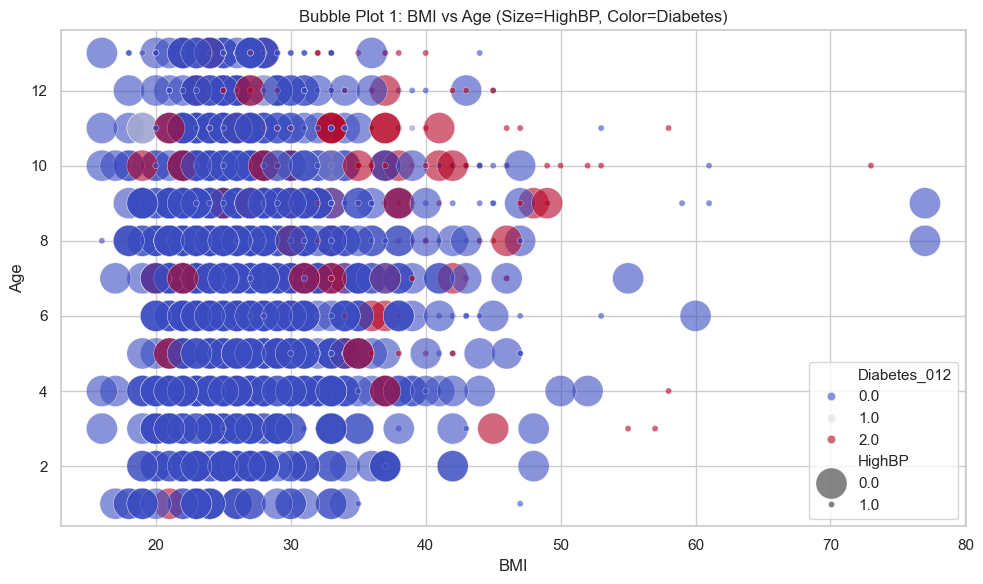

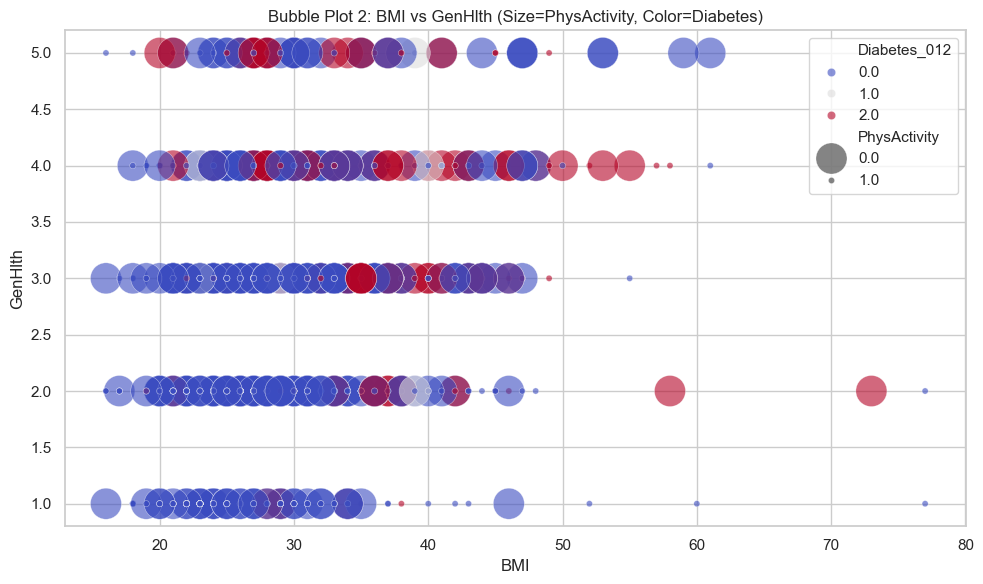

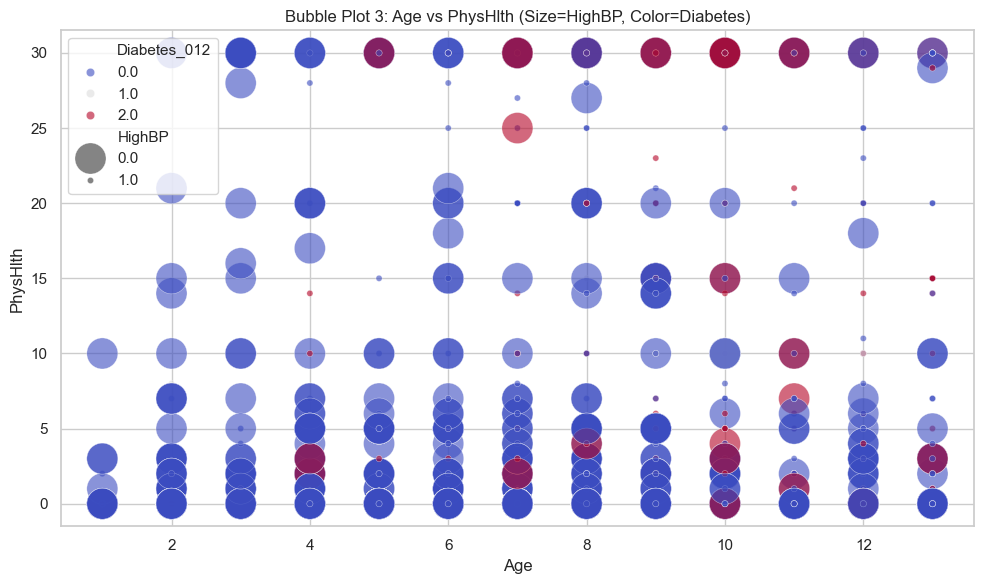

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(DATA_DIR / 'diabetes_012_health_indicators_BRFSS2015.csv')

# Sample for visualization
sample_df = df.sample(2000, random_state=42)

# Common settings
sns.set(style="whitegrid")

# Bubble Plot 1: BMI vs Age

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x='BMI', y='Age',
    size='HighBP', hue='Diabetes_012',
    sizes=(20, 500), alpha=0.6, palette='coolwarm'
)
plt.title('Bubble Plot 1: BMI vs Age (Size=HighBP, Color=Diabetes)')
plt.tight_layout()
plt.show()

# Bubble Plot 2: BMI vs GenHlth

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x='BMI', y='GenHlth',
    size='PhysActivity', hue='Diabetes_012',
    sizes=(20, 500), alpha=0.6, palette='coolwarm'
)
plt.title('Bubble Plot 2: BMI vs GenHlth (Size=PhysActivity, Color=Diabetes)')
plt.tight_layout()
plt.show()


# Bubble Plot 3: Age vs PhysHlth

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x='Age', y='PhysHlth',
    size='HighBP', hue='Diabetes_012',
    sizes=(20, 500), alpha=0.6, palette='coolwarm'
)
plt.title('Bubble Plot 3: Age vs PhysHlth (Size=HighBP, Color=Diabetes)')
plt.tight_layout()
plt.show()


## Diabetes: Principal component analysis

PCA is used to examine directions of variation in the standardized feature space and to evaluate how much information is captured by the first principal component.


In [4]:
# PCA component directions
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv(DATA_DIR / 'diabetes_012_health_indicators_BRFSS2015.csv')

# Drop non-numeric if any (this dataset is all numeric)
X = df.dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=5)  # first 5 components
pca.fit(X_scaled)

# Principal component directions
print("Principal Components (Directions):")
components_df = pd.DataFrame(pca.components_, columns=df.columns)
print(components_df)

for i, row in components_df.iterrows():
    print(f"PC{i+1}: {row.values}")

# Explained variance
print("\nExplained Variance by Each Component:")
print(pca.explained_variance_ratio_)


Principal Components (Directions):
   Diabetes_012    HighBP  HighChol  CholCheck       BMI    Smoker    Stroke  \
0      0.243626  0.260297  0.195329   0.042966  0.178362  0.146539  0.163444   
1      0.184568  0.307226  0.299322   0.231828 -0.004374  0.003707  0.103126   
2     -0.058168 -0.103430 -0.077462   0.083065 -0.134481 -0.173618  0.080445   
3      0.173721 -0.000205 -0.031032   0.209252  0.476627 -0.388514 -0.186849   
4     -0.081412 -0.048919  0.041435  -0.071561 -0.038888  0.340135  0.106901   

   HeartDiseaseorAttack  PhysActivity    Fruits  ...  AnyHealthcare  \
0              0.216778     -0.226381 -0.095541  ...      -0.036772   
1              0.211528      0.100989  0.158867  ...       0.356279   
2             -0.010210      0.132272  0.510213  ...       0.090792   
3             -0.192473     -0.122517 -0.179470  ...       0.262295   
4              0.167099      0.098308 -0.101282  ...       0.106287   

   NoDocbcCost   GenHlth  MentHlth  PhysHlth  DiffWalk   

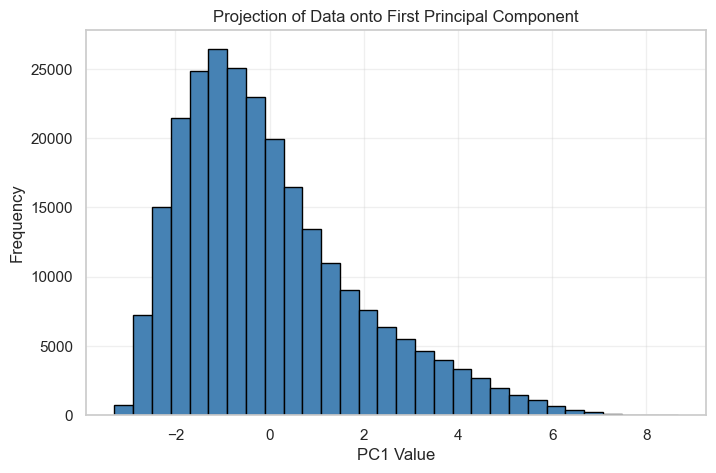

In [5]:
# Project the data onto the first principal component 

import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(DATA_DIR / 'diabetes_012_health_indicators_BRFSS2015.csv')

# Drop target column
X = df.drop(columns=['Diabetes_012'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
pca.fit(X_scaled)

# Project onto first principal component
pc1_projection = X_scaled.dot(pca.components_[0])

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(pc1_projection, bins=30, edgecolor='black')
plt.title('Projection of Data onto First Principal Component')
plt.xlabel('PC1 Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()


In [6]:
# Variance captured by the first principal component

# Calculate explained variance ratio for PC1
explained_variance = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_variance[0]*100:.2f}%")


Variance explained by PC1: 16.71%


## Diabetes: Baseline regression checks

The regression checks compare demographic, clinical, lifestyle, combined, and selected feature sets for predicting the diabetes status variable using a linear baseline.


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

# Load dataset
df = pd.read_csv(DATA_DIR / "diabetes_012_health_indicators_BRFSS2015.csv")
target = 'Diabetes_012'

# Define feature sets
feature_sets = {
    'Demographic': ['Age', 'Sex', 'Education', 'Income'],
    'Clinical': ['HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack'],
    'Lifestyle': ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump'],
    'All Features': [col for col in df.columns if col != target]
}

results = {}

# Train and evaluate for each set
for name, features in feature_sets.items():
    X = df[features]
    y = df[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    results[name] = r2

# Show results
print("R² Scores for Different Feature Sets:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


R² Scores for Different Feature Sets:
Demographic: 0.0618
Clinical: 0.1343
Lifestyle: 0.0231
All Features: 0.1733


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv(DATA_DIR / 'diabetes_012_health_indicators_BRFSS2015.csv')

target = 'Diabetes_012'
# Select top correlated features based on heatmap
top_features = ['HighBP', 'HighChol', 'BMI', 'Age']

results = {}

for feature in top_features:
    X = df[[feature]]
    y = df[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    results[feature] = r2

# Combine top features
X_multi = df[top_features]
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results['Combined Features'] = r2_score(y_test, y_pred)

# Show results
print("R² Scores for Selected Features:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


R² Scores for Selected Features:
HighBP: 0.0758
HighChol: 0.0489
BMI: 0.0490
Age: 0.0349
Combined Features: 0.1311


## Diabetes findings

The diabetes dataset is usable for exploratory analysis and baseline modeling, but most individual relationships are modest. Clinical variables such as high blood pressure, high cholesterol, BMI, heart disease history, and age are more useful than lifestyle variables alone. PCA suggests dimensionality reduction is possible, but the first principal component captures only a limited share of the variance, so one component is not enough to represent the full dataset.


# 2. Life Expectancy

The Life Expectancy dataset contains country-year public health, mortality, vaccination, economic, and education indicators. This section evaluates multivariate relationships and feature sets that predict life expectancy.


## Life Expectancy: Heatmap and bubble plots


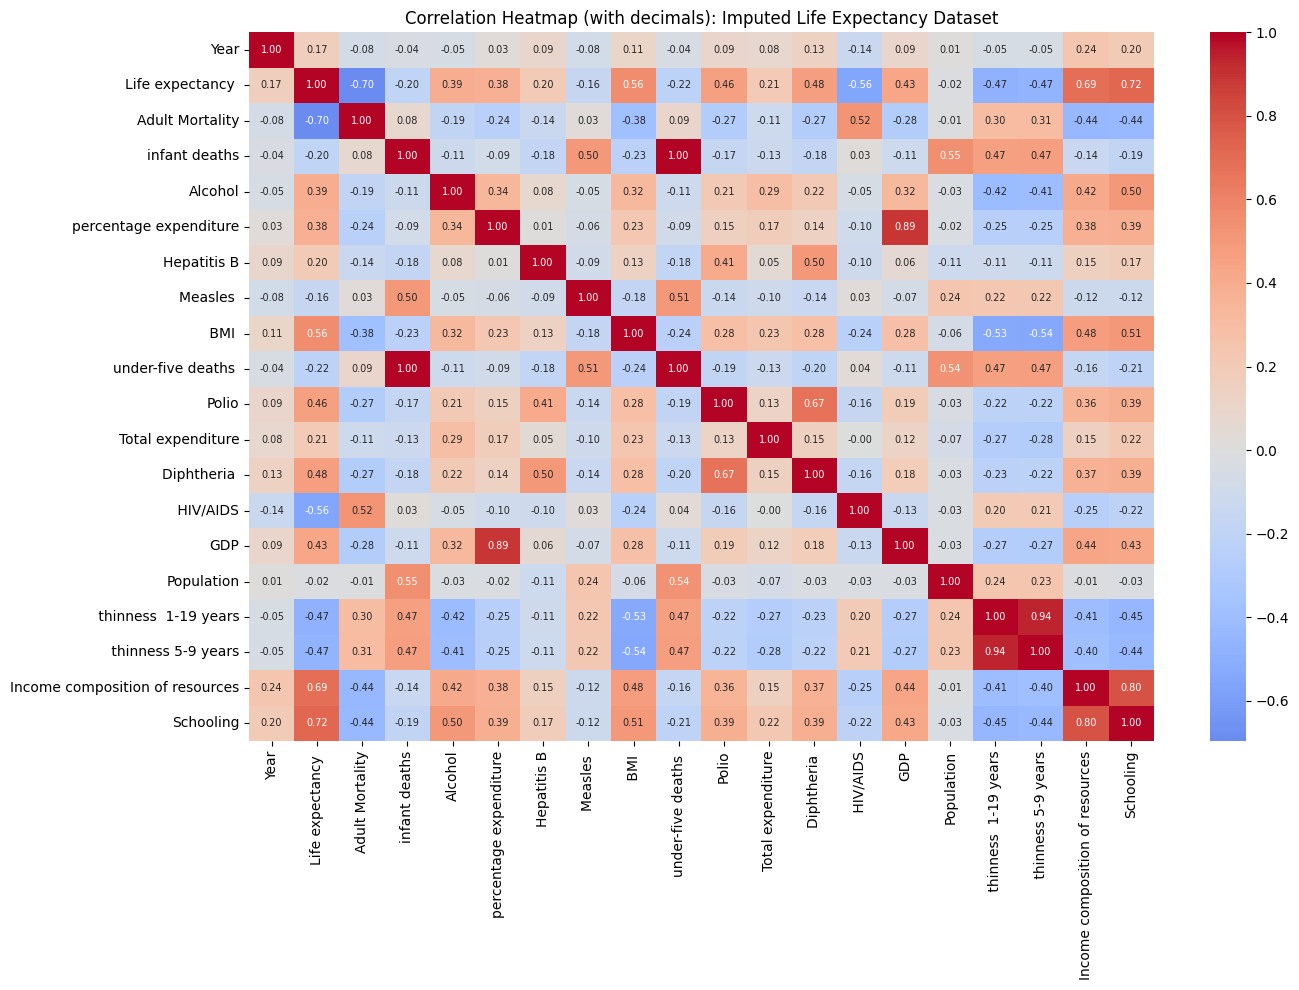

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the imputed Life Expectancy dataset
df = pd.read_csv(DATA_DIR / "Life Expectancy Data - mean_mode_imputed.csv")

# correlation matrix (numeric only)
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,          # show values in each cell
    fmt=".2f",           # decimals
    cmap="coolwarm",
    center=0,
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap (with decimals): Imputed Life Expectancy Dataset")
plt.tight_layout()
plt.show()


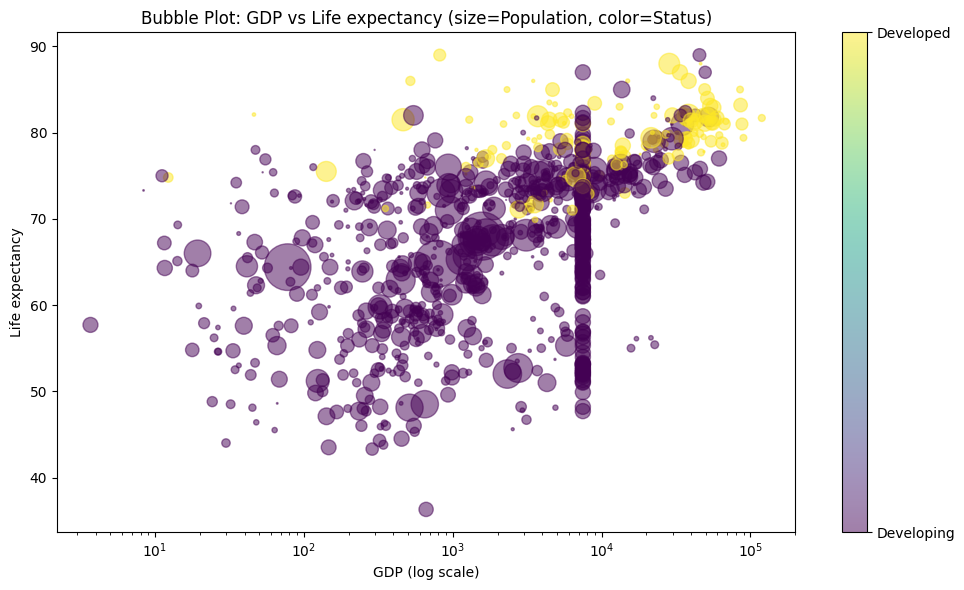

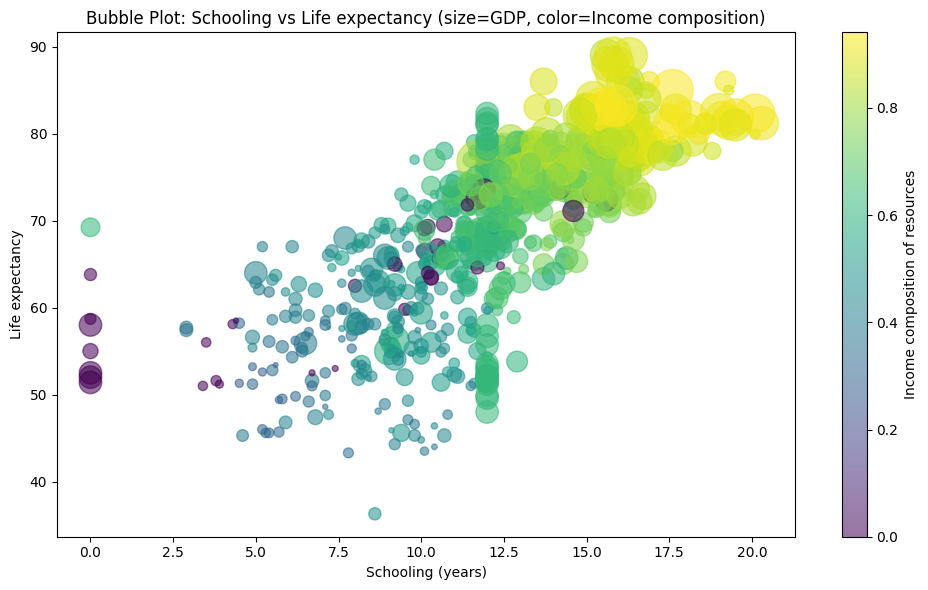

In [10]:
# 2. Draw bubble plots

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(DATA_DIR / "Life Expectancy Data - mean_mode_imputed.csv")

# clean column names (removes trailing spaces)
df.columns = df.columns.str.strip()

# keep a smaller sample for speed
plot_df = df.sample(1000, random_state=42).copy()

# Bubble Plot 1: GDP vs Life expectancy 
pop = plot_df["Population"].replace(0, np.nan)
sizes = np.sqrt(pop) / np.nanmax(np.sqrt(pop)) * 1200  # scale to nice bubble sizes

# map Status to colors
status_colors = plot_df["Status"].map({"Developing": 0, "Developed": 1}).fillna(0)

plt.figure(figsize=(10, 6))
sc = plt.scatter(
    plot_df["GDP"],
    plot_df["Life expectancy"],
    s=sizes,
    c=status_colors,
    alpha=0.5
)
plt.xscale("log")  # GDP is usually very skewed; log makes it readable
plt.xlabel("GDP (log scale)")
plt.ylabel("Life expectancy")
plt.title("Bubble Plot: GDP vs Life expectancy (size=Population, color=Status)")
cbar = plt.colorbar(sc, ticks=[0, 1])
cbar.ax.set_yticklabels(["Developing", "Developed"])
plt.tight_layout()
plt.show()

#bubble Plot 2: Schooling vs Life expectancy 
plot_df2 = df.sample(800, random_state=7).copy()

gdp = plot_df2["GDP"].replace(0, np.nan)
sizes2 = np.sqrt(gdp) / np.nanmax(np.sqrt(gdp)) * 900

plt.figure(figsize=(10, 6))
sc2 = plt.scatter(
    plot_df2["Schooling"],
    plot_df2["Life expectancy"],
    s=sizes2,
    c=plot_df2["Income composition of resources"],
    alpha=0.55
)
plt.xlabel("Schooling (years)")
plt.ylabel("Life expectancy")
plt.title("Bubble Plot: Schooling vs Life expectancy (size=GDP, color=Income composition)")
plt.colorbar(sc2, label="Income composition of resources")
plt.tight_layout()
plt.show()


## Life Expectancy: Principal component analysis

PCA is applied to the numeric predictor variables after standardization, with life expectancy kept as the target for interpretation.


Variance captured by PC1: 0.2918 (29.18%)


,PC1
0,3.952633
1,3.521790
2,3.596653
3,3.547884
4,3.699976


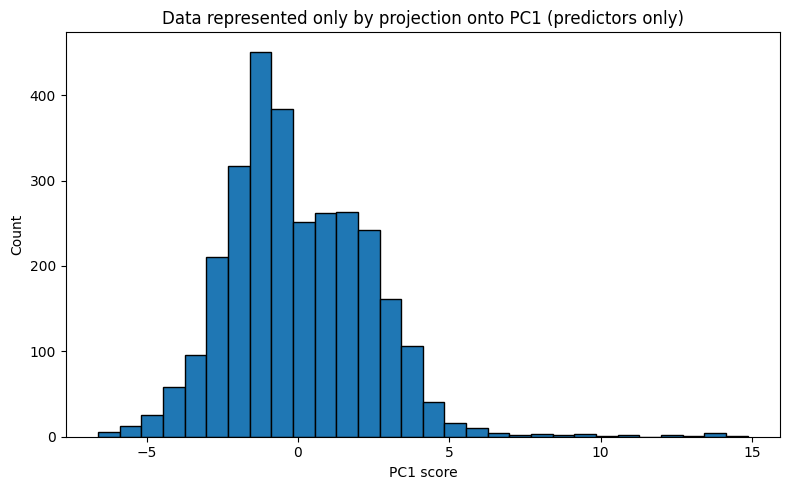


Top 10 absolute loadings for PC1:


,PC1_loading
thinness 1-19 years,0.322862
thinness 5-9 years,0.322450
Schooling,-0.320557
Income composition of resources,-0.303069
BMI,-0.283991
under-five deaths,0.239098
infant deaths,0.233735
GDP,-0.231095
Alcohol,-0.230474
Diphtheria,-0.226753


In [11]:
# PCA on predictors only
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv(DATA_DIR / "Life Expectancy Data - mean_mode_imputed.csv")
df.columns = df.columns.str.strip()

# Separate target (keep for later plots)
y = df["Life expectancy"]  

# Predictors for PCA: numeric columns only, exclude target
X = df.select_dtypes(include=[np.number]).drop(columns=["Life expectancy"])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with 1 component
pca1 = PCA(n_components=1, random_state=0)
pc1_scores = pca1.fit_transform(X_scaled).ravel()

# Variance captured by PC1
var_pc1 = pca1.explained_variance_ratio_[0]
print(f"Variance captured by PC1: {var_pc1:.4f} ({var_pc1*100:.2f}%)")

# 1D representation (projection onto PC1)
pc1_df = pd.DataFrame({"PC1": pc1_scores})
display(pc1_df.head())

# Histogram of PC1 scores
plt.figure(figsize=(8, 5))
plt.hist(pc1_scores, bins=30, edgecolor="black")
plt.title("Data represented only by projection onto PC1 (predictors only)")
plt.xlabel("PC1 score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Top loadings (which features drive PC1)
loadings = pd.Series(pca1.components_[0], index=X.columns)
loadings = loadings.reindex(loadings.abs().sort_values(ascending=False).index)

print("\nTop 10 absolute loadings for PC1:")
display(loadings.head(10).to_frame("PC1_loading"))


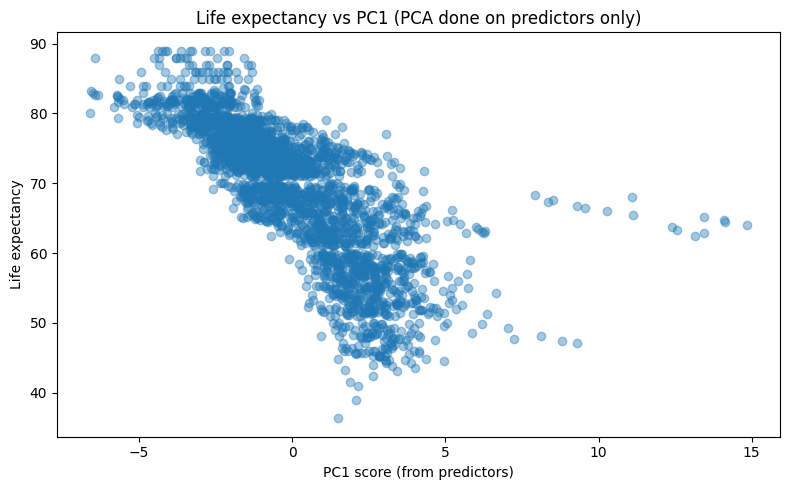

In [12]:
# relate PC1 to Life expectancy (scatter plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(pc1_scores, y, alpha=0.4)
plt.xlabel("PC1 score (from predictors)")
plt.ylabel("Life expectancy")
plt.title("Life expectancy vs PC1 (PCA done on predictors only)")
plt.tight_layout()
plt.show()


## Life Expectancy: Baseline regression checks

The regression section compares broad feature groups such as health, economy, social indicators, and combined predictors.


In [13]:
# Linear regression with different feature sets
# quick way to see which features are most useful predictors

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv(DATA_DIR / "Life Expectancy Data - mean_mode_imputed.csv")
df.columns = df.columns.str.strip()

# Use numeric columns only (linear regression needs numeric)
num_df = df.select_dtypes(include=[np.number]).copy()

# Pick the main target
TARGET = "Life expectancy"

def eval_feature_set(X, y, name="Model"):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    #rmse = mean_squared_error(y_test, preds, squared=False)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    # 5-fold CV R^2 for stability
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X, y, cv=cv, scoring="r2")

    print(f"\n{name}")
    print(f"  Test R^2  : {r2:.4f}")
    print(f"  Test RMSE : {rmse:.4f}")
    print(f"  CV R^2    : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

    return model

# Predict Life expectancy using different feature sets
y = num_df[TARGET]
X_all = num_df.drop(columns=[TARGET])

# Choose some reasonable feature groups
health_feats = [c for c in X_all.columns if c in [
    "Adult Mortality", "infant deaths", "under-five deaths", "BMI",
    "HIV/AIDS", "Measles", "Polio", "Diphtheria",
    "thinness  1-19 years", "thinness 5-9 years",
    "Total expenditure", "Alcohol", "Hepatitis B"
]]

economy_feats = [c for c in X_all.columns if c in [
    "GDP", "Population", "percentage expenditure"
]]

social_feats = [c for c in X_all.columns if c in [
    "Schooling", "Income composition of resources"
]]

def safe_X(cols):
    cols = [c for c in cols if c in X_all.columns]
    return X_all[cols] if len(cols) > 0 else None

models = {}

# All numeric predictors
models["All numeric predictors"] = eval_feature_set(X_all, y, "All numeric predictors")

# Health-only
X_health = safe_X(health_feats)
if X_health is not None:
    models["Health only"] = eval_feature_set(X_health, y, "Health only")
else:
    print("\nHealth only: skipped (no matching columns found)")

# Economy-only
X_econ = safe_X(economy_feats)
if X_econ is not None:
    models["Economy only"] = eval_feature_set(X_econ, y, "Economy only")
else:
    print("\nEconomy only: skipped (no matching columns found)")

# Social-only
X_social = safe_X(social_feats)
if X_social is not None:
    models["Social only"] = eval_feature_set(X_social, y, "Social only")
else:
    print("\nSocial only: skipped (no matching columns found)")

# Health + Social (often strong)
hs = list(dict.fromkeys(health_feats + social_feats))
X_hs = safe_X(hs)
if X_hs is not None:
    models["Health + Social"] = eval_feature_set(X_hs, y, "Health + Social")
else:
    print("\nHealth + Social: skipped (no matching columns found)")



All numeric predictors
  Test R^2  : 0.8227
  Test RMSE : 3.9193
  CV R^2    : 0.8137 ± 0.0136

Health only
  Test R^2  : 0.7526
  Test RMSE : 4.6292
  CV R^2    : 0.7421 ± 0.0190

Economy only
  Test R^2  : 0.2209
  Test RMSE : 8.2157
  CV R^2    : 0.1790 ± 0.0279

Social only
  Test R^2  : 0.5710
  Test RMSE : 6.0964
  CV R^2    : 0.5500 ± 0.0175

Health + Social
  Test R^2  : 0.8169
  Test RMSE : 3.9831
  CV R^2    : 0.8094 ± 0.0130


## Life Expectancy findings

The results are consistent with expectations: higher schooling, income composition, and stronger public health indicators tend to align with higher life expectancy, while adult mortality and HIV/AIDS burden align with lower life expectancy. PCA shows meaningful redundancy among health and development indicators, and the baseline regression results suggest that health and social indicators are especially useful predictors.


# 3. SUPPORT2 Clinical Outcomes

The SUPPORT2 dataset contains patient-level clinical, prognosis, cost, and survival-related variables. This section reviews multivariate patterns and baseline predictive relationships in the imputed clinical dataset.


## SUPPORT2: Heatmap and bubble plots


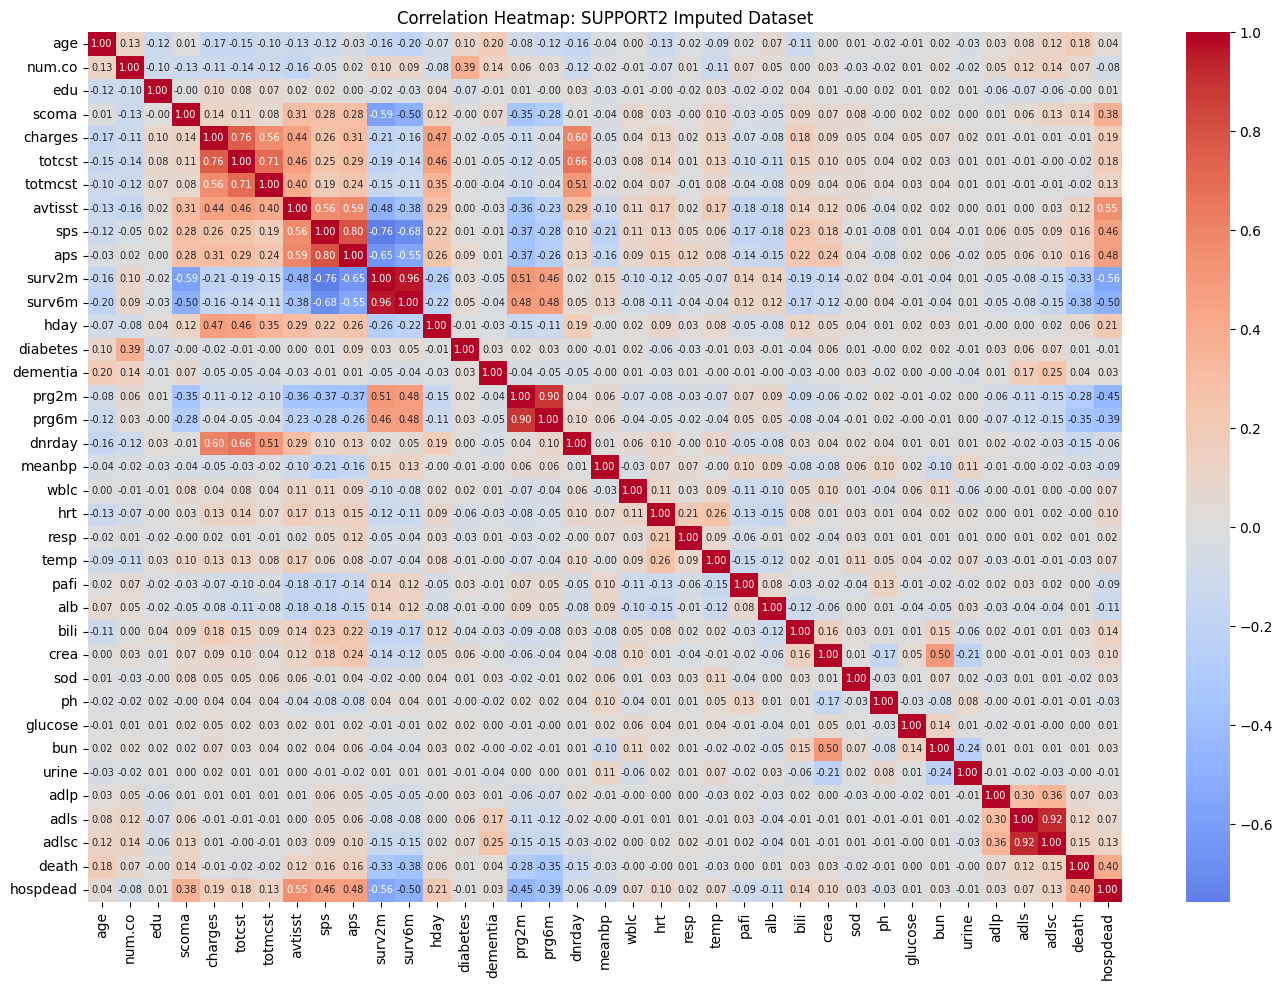

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load SUPPORT2 imputed dataset
df = pd.read_csv(DATA_DIR / "support2_imputed.csv")
df.columns = df.columns.str.strip()

# correlation matrix (numeric only)
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,      # show numbers in cells
    fmt=".2f",       # decimals 
    cmap="coolwarm",
    center=0,
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap: SUPPORT2 Imputed Dataset")
plt.tight_layout()
plt.show()


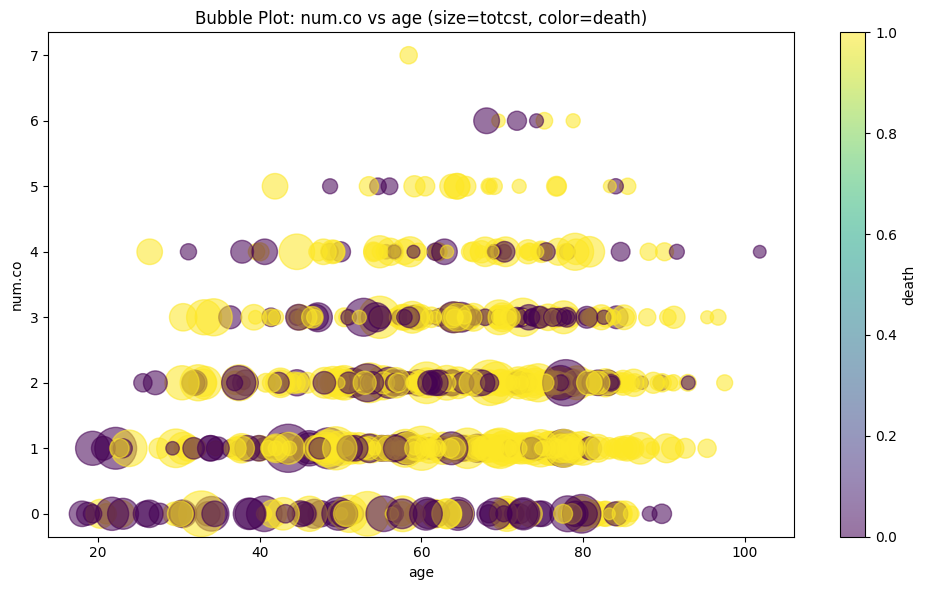

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load SUPPORT2 (imputed)
df = pd.read_csv(DATA_DIR / "support2_imputed.csv")
df.columns = df.columns.str.strip()

# Use only numeric columns and sample so it plots fast
num_df = df.select_dtypes(include=[np.number]).sample(800, random_state=42)

# Bubble Plot 1: age vs survival time
x = "age" if "age" in num_df.columns else num_df.columns[0]
y = "d.time" if "d.time" in num_df.columns else num_df.columns[1]
size_col = "totcst" if "totcst" in num_df.columns else num_df.columns[2]
color_col = "death" if "death" in num_df.columns else y

# bubble sizes (scaled)
sizes = num_df[size_col].abs()
sizes = (np.sqrt(sizes) / np.sqrt(sizes).max()) * 1200

plt.figure(figsize=(10, 6))
sc = plt.scatter(num_df[x], num_df[y], s=sizes, c=num_df[color_col], alpha=0.55)
plt.xlabel(x)
plt.ylabel(y)
plt.title(f"Bubble Plot: {y} vs {x} (size={size_col}, color={color_col})")
plt.colorbar(sc, label=color_col)
plt.tight_layout()
plt.show()


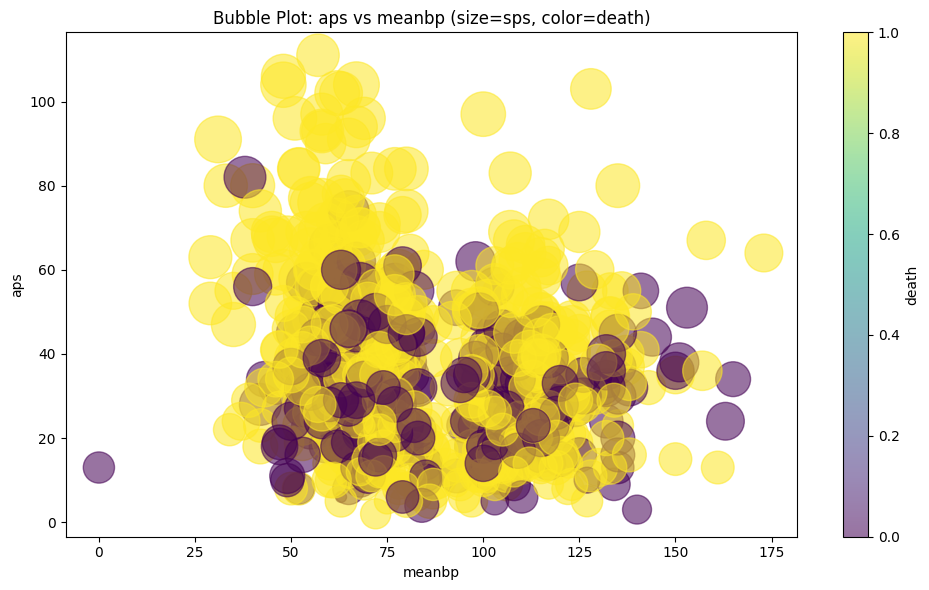

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Bubble Plot 2: pick different numeric columns 
cols = list(num_df.columns)

x2 = "meanbp" if "meanbp" in cols else cols[0]
y2 = "aps" if "aps" in cols else cols[1]
size_col2 = "sps" if "sps" in cols else cols[2]
color_col2 = "death" if "death" in cols else y2

sizes2 = num_df[size_col2].abs()
sizes2 = (np.sqrt(sizes2) / np.sqrt(sizes2).max()) * 1200

plt.figure(figsize=(10, 6))
sc2 = plt.scatter(num_df[x2], num_df[y2], s=sizes2, c=num_df[color_col2], alpha=0.55)
plt.xlabel(x2)
plt.ylabel(y2)
plt.title(f"Bubble Plot: {y2} vs {x2} (size={size_col2}, color={color_col2})")
plt.colorbar(sc2, label=color_col2)
plt.tight_layout()
plt.show()


## SUPPORT2: Principal component analysis

PCA is used to summarize overlap among clinical severity, prognosis, survival, and cost-related variables.


Variance captured by PC1: 0.1612 (16.12%)


,PC1
0,-0.726857
1,-5.246547
2,1.125632
3,1.778258
4,0.954628


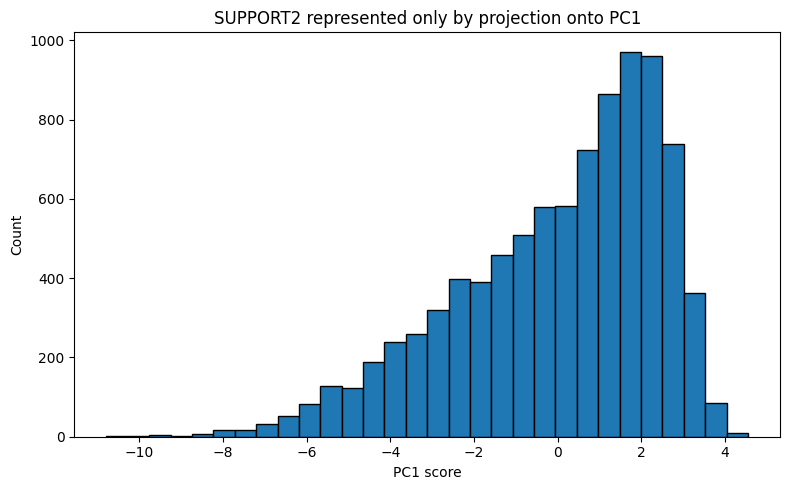


Top 10 absolute loadings for PC1:


,PC1_loading
surv2m,0.346999
sps,-0.318986
surv6m,0.318477
aps,-0.312384
avtisst,-0.298715
hospdead,-0.276253
prg2m,0.255458
prg6m,0.219007
scoma,-0.212801
totcst,-0.210584


In [ ]:
# PCA: represent SUPPORT2 data using only the first principal component (PC1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv(DATA_DIR / "support2_imputed.csv")
df.columns = df.columns.str.strip()

# PCA needs numeric data
X = df.select_dtypes(include=[np.number]).copy()

# Standardize numeric features before PCA
X_scaled = StandardScaler().fit_transform(X)

pca1 = PCA(n_components=1, random_state=0)
pc1_scores = pca1.fit_transform(X_scaled).ravel()

# How much variance PC1 captures
var_pc1 = pca1.explained_variance_ratio_[0]
print(f"Variance captured by PC1: {var_pc1:.4f} ({var_pc1*100:.2f}%)")

# 1D representation: projection onto PC1
pc1_df = pd.DataFrame({"PC1": pc1_scores})
display(pc1_df.head())

# Visualize the 1D projection
plt.figure(figsize=(8, 5))
plt.hist(pc1_scores, bins=30, edgecolor="black")
plt.title("SUPPORT2 represented only by projection onto PC1")
plt.xlabel("PC1 score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# show top features that define PC1 (largest absolute loadings)
loadings = pd.Series(pca1.components_[0], index=X.columns).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTop 10 absolute loadings for PC1:")
display(loadings.head(10).to_frame("PC1_loading"))


## SUPPORT2: Baseline regression checks

The regression check compares broad clinical feature groups and identifies the strongest coefficient magnitudes in the full baseline model.


In [18]:
# Linear regression: compare a few feature groups and show top predictors

import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv(DATA_DIR / "support2_imputed.csv")
df.columns = df.columns.str.strip()
D = df.select_dtypes(include=[np.number]).copy()

target = next((c for c in ["d.time","death","totcst","time","dead"] if c in D.columns), None)
if target is None: raise ValueError("Pick a target from: " + ", ".join(D.columns))

y = D[target]
X = D.drop(columns=[target])

def run(cols, name):
    cols = [c for c in cols if c in X.columns]
    if not cols: return None
    Xtr, Xte, ytr, yte = train_test_split(X[cols], y, test_size=0.2, random_state=42)
    m = make_pipeline(StandardScaler(), LinearRegression())
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    rmse = np.sqrt(mean_squared_error(yte, p))
    print(f"{name}: R2={r2_score(yte,p):.3f}, RMSE={rmse:.3f}")
    return m

print("Target:", target)
m_all = run(list(X.columns), "All")
run(["age","sex","edu","race"], "Demo")
run(["meanbp","resp","temp","wblc","crea","sod","hrt"], "Vitals/Labs")
run(["aps","sps","scoma"], "Severity")

# top predictors from the full model
coefs = pd.Series(m_all.named_steps["linearregression"].coef_, index=X.columns)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10)
print("\nTop predictors (by |coef| from full model):")
display(top.to_frame("coef"))


Target: death
All: R2=0.320, RMSE=0.387
Demo: R2=0.041, RMSE=0.459
Vitals/Labs: R2=0.002, RMSE=0.468
Severity: R2=0.034, RMSE=0.461

Top predictors (by |coef| from full model):


,coef
surv6m,-0.344127
surv2m,0.250597
hospdead,0.166888
prg6m,-0.134942
prg2m,0.086902
sps,-0.058895
num.co,0.032148
dnrday,-0.024989
aps,0.021945
adlsc,0.017713


## SUPPORT2 findings

The SUPPORT2 dataset shows realistic clinical structure. Severity, prognosis, and survival-related variables overlap substantially, which makes PCA useful for summarizing shared variation. Cost and outcome variables can contain extreme values, which should be handled carefully before more advanced modeling. Baseline linear regression gives a first-pass view of predictive signal, but clinical interpretation requires caution because many variables are correlated and may reflect disease severity or treatment intensity.

# Overall conclusion

Across the three datasets, multivariate EDA confirms that the data are usable for healthcare analytics and later modeling. The strongest relationships are generally clinically or contextually plausible, but many variables are redundant, skewed, ordinal, or affected by confounding. PCA can reduce dimensionality, but one principal component is usually not enough to capture the full structure. These findings support careful feature selection, robust preprocessing, and cautious interpretation before predictive modeling.
